## Classification with PyTorch

In [59]:
import sklearn
from sklearn.datasets import make_circles
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from torch import nn
import requests
from pathlib import Path

In [60]:
n_samples = 1000

X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state=67)

In [61]:
len(X), len(y)

(1000, 1000)

In [62]:
circles = pd.DataFrame({"X1" : X[: , 0],
                        "X2" : X[:,1],
                        "label" : y})
circles.head()

,X1,X2,label
0,0.233230,0.810821,1
1,0.175660,-1.000523,0
2,-0.606525,0.544122,1
3,0.453224,-0.673099,1
4,0.133497,0.836877,1


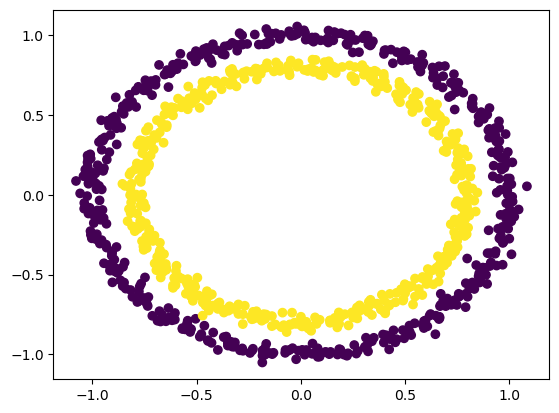

In [63]:
plt.scatter(x = X[:,0],
            y = X[:,1],
            c = y)
plt.show()

In [64]:
## Convert our data into tensors

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [65]:
type(X),type(y),X.dtype, y.dtype

(torch.Tensor, torch.Tensor, torch.float32, torch.float32)

In [66]:
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2 , random_state= 67)

In [67]:
#Device agnostic code

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [68]:
#Creating a model

class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features= 2, out_features= 5)
    self.layer_2 = nn.Linear(in_features= 5, out_features= 1)

  def forward(self, x):
    return self.layer_2(self.layer_1(x))
  
model_0  = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [69]:
#Create same model as above with nn.sequential

model_0 = nn.Sequential(
  nn.Linear(in_features= 2, out_features= 5),
  nn.Linear(in_features=5, out_features= 1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [70]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.2138,  0.0263],
                      [ 0.1883,  0.0429],
                      [-0.3092,  0.2258],
                      [ 0.2110, -0.5847],
                      [-0.1600,  0.2572]])),
             ('0.bias', tensor([-0.3691,  0.5009,  0.3315,  0.4882,  0.2810])),
             ('1.weight',
              tensor([[ 0.3172,  0.1063,  0.0332, -0.0218, -0.3968]])),
             ('1.bias', tensor([-0.0564]))])

In [71]:
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
untrained_preds

tensor([[-0.2203],
        [-0.1180],
        [-0.1150],
        [-0.1956],
        [-0.2987],
        [-0.3772],
        [-0.1896],
        [-0.1928],
        [-0.2564],
        [-0.2503],
        [-0.3116],
        [-0.1973],
        [-0.2095],
        [-0.0950],
        [-0.1944],
        [-0.2832],
        [-0.2655],
        [-0.3327],
        [-0.2096],
        [-0.1063],
        [-0.3168],
        [-0.1331],
        [-0.3318],
        [-0.2719],
        [-0.1212],
        [-0.3179],
        [-0.2555],
        [-0.1347],
        [-0.1110],
        [-0.3439],
        [-0.1296],
        [-0.1164],
        [-0.3416],
        [-0.1273],
        [-0.2512],
        [-0.3317],
        [-0.2856],
        [-0.3527],
        [-0.3647],
        [-0.0963],
        [-0.3853],
        [-0.2804],
        [-0.3237],
        [-0.3533],
        [-0.2665],
        [-0.2650],
        [-0.3851],
        [-0.3395],
        [-0.3245],
        [-0.3545],
        [-0.2091],
        [-0.1211],
        [-0.

In [72]:
## Setup loss functions and optimizer

loss_fn = nn.BCEWithLogitsLoss() #Cuz classification problem

optimizer = torch.optim.SGD(params= model_0.parameters(), lr = 0.1)

In [73]:
def accuracy_fn(y_true, y_preds):
  correct = torch.eq(y_true,y_preds).sum().item()
  acc = (correct/len(y_preds)) * 100
  return acc

In [74]:
##We now need to create the training loop for our model

model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test[:5].to(device))
y_logits

tensor([[-0.2203],
        [-0.1180],
        [-0.1150],
        [-0.1956],
        [-0.2987]])

In [75]:
y_test[:5]

tensor([1., 1., 1., 0., 0.])

In [76]:
## We use the sigmoid activation function on our model's logits(raw predictions out of the neural network) to turn them into prediction probabilites

y_preds_probs = torch.sigmoid(y_logits)
y_preds_probs

tensor([[0.4452],
        [0.4705],
        [0.4713],
        [0.4513],
        [0.4259]])

In [77]:
y_preds = torch.round(y_preds_probs)
y_preds

#in one line

y_preds_labels = torch.round(torch.sigmoid(model_0(X_test[:5].to(device))))

In [78]:
print(torch.eq(y_preds.squeeze(), y_preds_labels.squeeze()))

y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 0., 0., 0.])

In [79]:
## Create a training loop

torch.manual_seed(67)

epochs = 100

X_train, y_train, X_test, y_test = X_train.to(device), y_train.to(device), X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  ##Training
  model_0.train()

  y_logits = model_0(X_train).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train) ## here loss function is BCE with Logits so we expect logits as inputs rather then y_preds
  acc = accuracy_fn(y_train, y_preds)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  #Testing
  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_test, test_preds)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.70001, Accuracy: 50.50% | Test Loss: 0.70377, Test acc: 48.00%
Epoch: 10 | Loss: 0.69627, Accuracy: 50.12% | Test Loss: 0.69837, Test acc: 47.00%
Epoch: 20 | Loss: 0.69484, Accuracy: 43.75% | Test Loss: 0.69600, Test acc: 46.50%
Epoch: 30 | Loss: 0.69423, Accuracy: 46.38% | Test Loss: 0.69491, Test acc: 47.50%
Epoch: 40 | Loss: 0.69392, Accuracy: 48.25% | Test Loss: 0.69439, Test acc: 47.50%
Epoch: 50 | Loss: 0.69373, Accuracy: 49.12% | Test Loss: 0.69415, Test acc: 45.50%


Epoch: 60 | Loss: 0.69359, Accuracy: 49.50% | Test Loss: 0.69406, Test acc: 46.50%
Epoch: 70 | Loss: 0.69349, Accuracy: 49.88% | Test Loss: 0.69404, Test acc: 47.00%
Epoch: 80 | Loss: 0.69340, Accuracy: 48.88% | Test Loss: 0.69407, Test acc: 47.00%
Epoch: 90 | Loss: 0.69333, Accuracy: 49.25% | Test Loss: 0.69412, Test acc: 48.50%


In [80]:
if Path("helper_functions.py").is_file():
  print("Already downloaded! Skipping downloading.")
else:
  print("Downloading Helper functions")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions , plot_decision_boundary

Already downloaded! Skipping downloading.


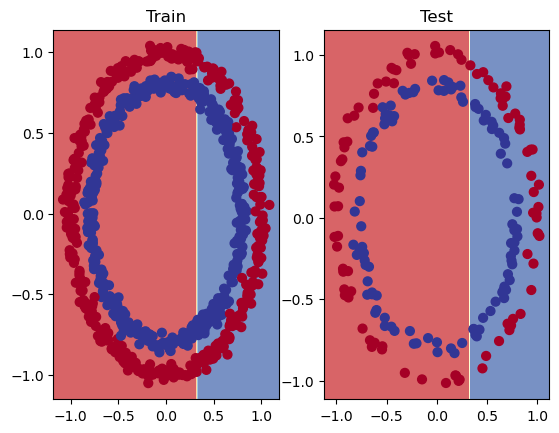

In [81]:
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [82]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features= 2, out_features= 10)
    self.layer2 = nn.Linear(in_features=10, out_features= 10)
    self.layer3 = nn.Linear(in_features= 10, out_features= 1)
  
  def forward(self,x):
    return self.layer3(self.layer2(self.layer1(x)))
  
model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
)

In [83]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params = model_1.parameters(), lr = 0.1)

In [84]:
torch.manual_seed(67)

epochs = 1000

X_train,y_train, X_test, y_test = X_train.to(device), y_train.to(device), X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_1.train()

  y_logits = model_1(X_train).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_preds)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()


  model_1.eval()

  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_test, test_preds)

  if epoch %100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.72312, Accuracy: 42.00% | Test Loss: 0.72065, Test acc: 42.00%
Epoch: 100 | Loss: 0.69311, Accuracy: 43.75% | Test Loss: 0.69388, Test acc: 41.00%
Epoch: 200 | Loss: 0.69293, Accuracy: 50.00% | Test Loss: 0.69495, Test acc: 40.50%
Epoch: 300 | Loss: 0.69291, Accuracy: 49.25% | Test Loss: 0.69514, Test acc: 44.50%
Epoch: 400 | Loss: 0.69291, Accuracy: 49.88% | Test Loss: 0.69520, Test acc: 46.00%
Epoch: 500 | Loss: 0.69291, Accuracy: 49.75% | Test Loss: 0.69521, Test acc: 45.50%
Epoch: 600 | Loss: 0.69291, Accuracy: 49.75% | Test Loss: 0.69522, Test acc: 46.00%
Epoch: 700 | Loss: 0.69291, Accuracy: 49.88% | Test Loss: 0.69522, Test acc: 46.00%
Epoch: 800 | Loss: 0.69291, Accuracy: 49.88% | Test Loss: 0.69522, Test acc: 46.00%
Epoch: 900 | Loss: 0.69291, Accuracy: 49.88% | Test Loss: 0.69523, Test acc: 46.00%


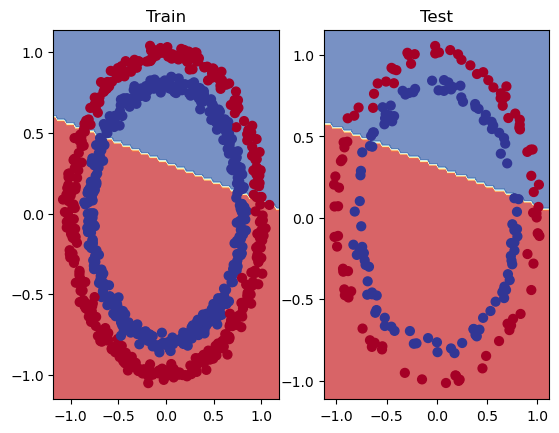

In [85]:
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

In [86]:
## Test our data on the older dataset

weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

X_regression= torch.arange(start,end,step).unsqueeze(dim= 1)
y_regression = weight * X_regression + bias

In [87]:
X_train_regression , y_train_regression = X_regression[:80], y_regression[:80]
X_test_regression , y_test_regression = X_regression[80:], y_regression[80:]

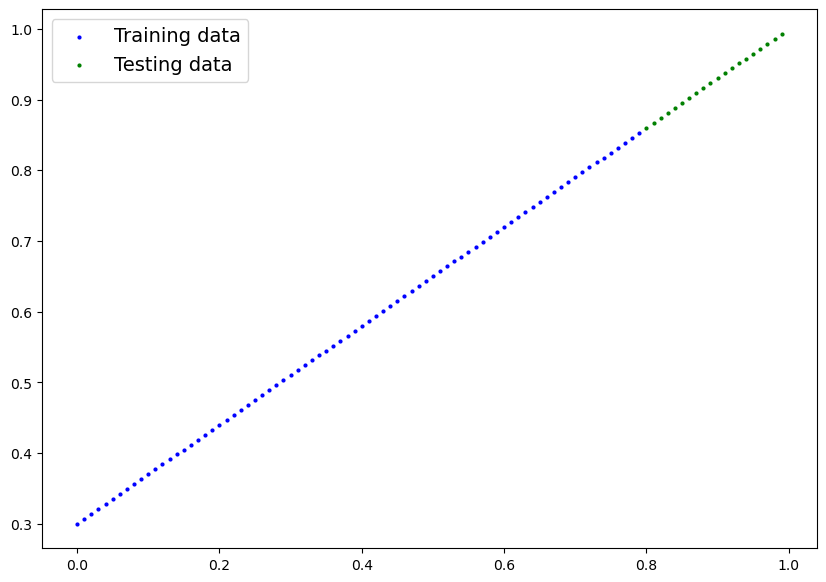

In [88]:
plot_predictions(train_data= X_train_regression, train_labels= y_train_regression, test_data= X_test_regression, test_labels= y_test_regression)

In [89]:
model_2 = nn.Sequential(
  nn.Linear(in_features= 1, out_features= 10),
  nn.Linear(in_features= 10, out_features= 10),
  nn.Linear(in_features= 10, out_features= 1)
).to(device)

In [101]:
loss_fn = nn.L1Loss()
optimizer= torch.optim.SGD(params= model_2.parameters(), lr = 0.01)

In [102]:
torch.manual_seed(67)

epochs = 1000

X_train_regression, y_train_regression, X_test_regression, y_test_regression = X_train_regression.to(device), y_train_regression.to(device), X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
  model_2.train()

  y_preds = model_2(X_train_regression)
  loss = loss_fn(y_preds, y_train_regression)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_2.eval()
  with torch.inference_mode():
    test_preds = model_2(X_test_regression)
    test_loss = loss_fn(test_preds, y_test_regression)
  
  if epoch %100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")

Epoch: 0 | Loss: 0.00058 | Test Loss: 0.01288
Epoch: 100 | Loss: 0.00393 | Test Loss: 0.01357
Epoch: 200 | Loss: 0.00605 | Test Loss: 0.01353
Epoch: 300 | Loss: 0.00604 | Test Loss: 0.01382
Epoch: 400 | Loss: 0.00602 | Test Loss: 0.01405
Epoch: 500 | Loss: 0.00601 | Test Loss: 0.01427
Epoch: 600 | Loss: 0.00570 | Test Loss: 0.01415
Epoch: 700 | Loss: 0.00569 | Test Loss: 0.01340
Epoch: 800 | Loss: 0.00599 | Test Loss: 0.01359
Epoch: 900 | Loss: 0.00598 | Test Loss: 0.01377


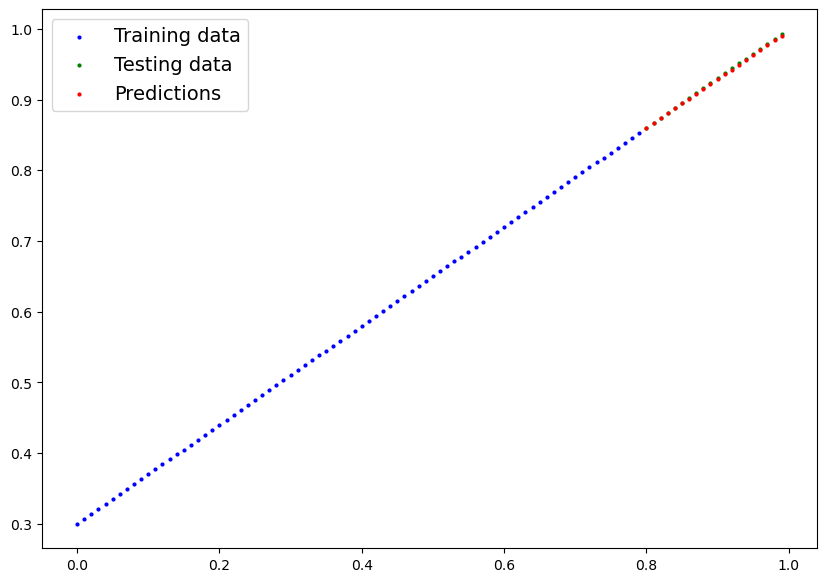

In [103]:
model_2.eval()

with torch.inference_mode():
  y_preds = model_2(X_test_regression)

plot_predictions(train_data= X_train_regression, train_labels=  y_train_regression, test_data= X_test_regression, test_labels= y_test_regression, predictions= y_preds)